In [1]:
# we import the pandas library 
import pandas as pd

In [2]:
df_penguins = pd.read_csv('../../W4_Pandas_And_Environmental_Data/Data/palmer_penguin_data.csv',
                          sep = ',',
                          na_values='NA',
                          skiprows= 1,
                          index_col=0   # Use the first column as the index of the DataFrame
                          )
df_penguins

df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [24]:
columns = ['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_penguins[columns].groupby(by='species').mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


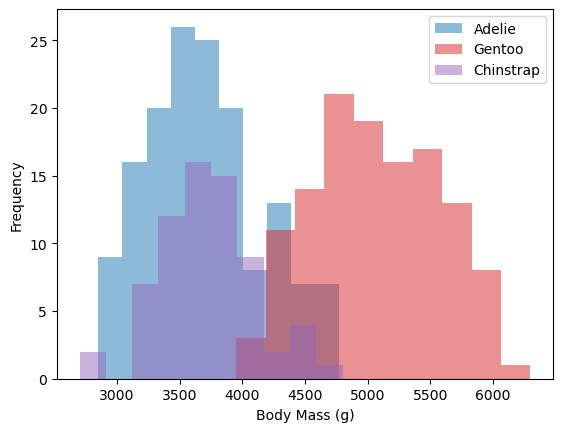

In [28]:
import matplotlib.pyplot as plt
fix,ax = plt.subplots()
df_Adelie.plot(kind='hist', y = 'body_mass_g', color = 'tab:blue', alpha = 0.5, ax =ax )
df_Gentoo.plot(kind='hist', y = 'body_mass_g', color = 'tab:red', alpha = 0.5, ax =ax )
df_Chinstrap.plot(kind='hist', y = 'body_mass_g', color = 'tab:purple', alpha = 0.5, ax =ax)
plt.xlabel('Body Mass (g)')
plt.legend(['Adelie', 'Gentoo', 'Chinstrap'])

In [ ]:
df_Adelie = df_penguins.loc[df_penguins.species == 'Adelie']
df_Gentoo = df_penguins.loc[df_penguins.species == 'Gentoo']
df_Chinstrap = df_penguins.loc[df_penguins.species == 'Chinstrap']

In [36]:
import scipy.stats

x = df_Adelie['body_mass_g']
y = df_Gentoo['body_mass_g']

scipy.stats.ttest_ind(x, y, nan_policy = 'omit', alternative='two-sided', equal_var = False)

TtestResult(statistic=np.float64(-23.38602766996551), pvalue=np.float64(7.709823145147336e-65), df=np.float64(249.64255363131144))

In [30]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

data = df_penguins.dropna()

model = ols('body_mass_g ~ C(species)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                  sum_sq     df           F        PR(>F)
C(species)  1.451902e+08    2.0  341.894895  3.744505e-81
Residual    7.006945e+07  330.0         NaN           NaN


In [33]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=data['body_mass_g'],   # Data values
                          groups=data['species'], # Group labels
                          alpha=0.05)  

In [34]:
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726    0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487    0.0 1194.4304 1524.2671   True
---------------------------------------------------------------
